# 12-Data Observability & Lineage

In the previous eleven lessons, we engineered a complete Enterprise Modern Data Stack. We built ELT ingestion, Dimensional Modeling, dbt Transformations, Airflow Orchestration, Debezium CDC Streams, Kafka, Lakehouse Storage, and strict Schema Contracts.

However, when you wire 500 of these complex pipelines together in a Fortune 500 company, you create an incomprehensible topological graph. If the CFO opens the `Total_Revenue_Q3` dashboard on a Friday morning and it shows `$0.00`, how do you debug it?

* Did the Kafka stream drop events?
* Did the dbt transform fail to execute?
* Did the Airflow schedule stall?
* Did a software engineer change the upstream source table?

To guarantee system reliability at scale, we must move beyond simply executing pipelines. We must engineer **Data Observability**. We must mathematically trace the exact origin, transformation, and destination of every single byte of data across the entire platform. The industry standard for capturing this physical provenance is **OpenLineage**.

Let's set up our environment to engineer data lineage tracking.

In [1]:
# Required installations: pip install openlineage-python matplotlib seaborn pandas
import json
import uuid
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Data Observability Engine Initialized.")

✅ Systems Architecture & Data Observability Engine Initialized.


# 1. The Mathematics of Data Lineage

Data Lineage is not a diagram drawn by hand; it is a continuously updating, machine-readable Directed Acyclic Graph (DAG) constructed from distributed telemetry events.

Let $J$ be an executable Job (e.g., an Airflow Task or a dbt Model).
Let $D$ be a physical Dataset (e.g., a Kafka Topic or a Postgres Table).

The **OpenLineage Specification** states that every time $J$ executes, it emits a `RunEvent` to a central tracking server (like Marquez or DataHub). The mathematical structure of this event explicitly links the input datasets to the output datasets:


$$\text{Event}(J_{run}) \implies \{D_{in}\} \xrightarrow{J} \{D_{out}\}$$

By capturing these discrete events independently from hundreds of disconnected systems, the central observability server mathematically reconstructs the global pipeline topology using Graph Theory. If $D_{out}$ of Job $A$ exactly matches $D_{in}$ of Job $B$, an implicit edge is drawn:


$$J_A \rightarrow D_{intermediate} \rightarrow J_B$$

This provides total visibility. If $D_{final}$ breaks, you can trace the edges backwards through the graph to find the exact upstream system that poisoned the pipeline.

# 2. Architecting the OpenLineage Event Emitter

In production, tools like Airflow and dbt have native integrations that emit OpenLineage events automatically. However, to understand the physics of observability, we will build the raw JSON payload manually.

We will simulate a pipeline that extracts data from a **Source Postgres Table** and writes it to a **Target Snowflake Table**. We will construct the exact OpenLineage JSON payload that proves this movement occurred.

In [2]:
# --- 📡 STEP 1: Constructing the OpenLineage Telemetry Payload ---

def generate_lineage_event(job_name: str, input_dataset: str, output_dataset: str, status: str):
    """
    Constructs a strict OpenLineage-compliant JSON event.
    This event proves that 'job_name' mathematically connected 'input_dataset' to 'output_dataset'.
    """
    # 1. Spacetime Coordinate & Unique Run ID
    event_time = datetime.now(timezone.utc).isoformat()
    run_id = str(uuid.uuid4())
    
    # 2. The Core OpenLineage Schema
    openlineage_payload = {
        "eventType": status, # e.g., START, COMPLETE, FAIL
        "eventTime": event_time,
        "run": {
            "runId": run_id
        },
        "job": {
            "namespace": "enterprise.data_engineering",
            "name": job_name
        },
        
        # 3. The Inputs (Where did the data come from?)
        "inputs": [
            {
                "namespace": "postgres://production-db:5432",
                "name": input_dataset,
                # Optional: We can even pass the exact schema at the time of execution
                "facets": {
                    "schema": {
                        "_producer": "https://github.com/OpenLineage/OpenLineage",
                        "_schemaURL": "https://openlineage.io/spec/facets/1-0-0/SchemaDatasetFacet.json#/$defs/SchemaDatasetFacet",
                        "fields": [
                            {"name": "user_id", "type": "INTEGER"},
                            {"name": "purchase_amount", "type": "FLOAT"}
                        ]
                    }
                }
            }
        ],
        
        # 4. The Outputs (Where did the data go?)
        "outputs": [
            {
                "namespace": "snowflake://enterprise-account",
                "name": output_dataset
            }
        ],
        "producer": "https://github.com/OpenLineage/OpenLineage/tree/main/client/python"
    }
    
    return json.dumps(openlineage_payload, indent=2)

# --- 🚀 STEP 2: Executing the Simulated Pipeline and Emitting Telemetry ---
print("--- 🚀 Executing 'Load_Sales_Data' Pipeline ---")

# Step A: The Job Starts
start_event = generate_lineage_event(
    job_name="Load_Sales_Data", 
    input_dataset="public.raw_transactions", 
    output_dataset="analytics.fact_sales", 
    status="START"
)
print("\n[Telemetry]: START Event Emitted to Observability Server.")

# (Simulated physical data movement happens here in Python/SQL)

# Step B: The Job Completes Successfully
complete_event = generate_lineage_event(
    job_name="Load_Sales_Data", 
    input_dataset="public.raw_transactions", 
    output_dataset="analytics.fact_sales", 
    status="COMPLETE"
)

print("\n[Telemetry]: COMPLETE Event Emitted to Observability Server.")
print("\n--- 📝 Raw OpenLineage Payload Verification ---")
print(complete_event)

print("\n--- 💡 Engineering Insight ---")
print("Look at the raw JSON payload. By standardizing this format, it doesn't matter if the job was run by Airflow, PySpark, or a random Python script. The central observability server (like DataHub) ingests this JSON, parses the `inputs` and `outputs` arrays, and permanently stores the topological link. If a downstream dashboard relies on `analytics.fact_sales`, the CFO can instantly see that it is mathematically dependent on `public.raw_transactions` in the Postgres database.")

--- 🚀 Executing 'Load_Sales_Data' Pipeline ---

[Telemetry]: START Event Emitted to Observability Server.

[Telemetry]: COMPLETE Event Emitted to Observability Server.

--- 📝 Raw OpenLineage Payload Verification ---
{
  "eventType": "COMPLETE",
  "eventTime": "2026-06-24T13:05:27.823175+00:00",
  "run": {
    "runId": "d296d611-26d9-4454-801c-24d21fab0fc6"
  },
  "job": {
    "namespace": "enterprise.data_engineering",
    "name": "Load_Sales_Data"
  },
  "inputs": [
    {
      "namespace": "postgres://production-db:5432",
      "name": "public.raw_transactions",
      "facets": {
        "schema": {
          "_producer": "https://github.com/OpenLineage/OpenLineage",
          "_schemaURL": "https://openlineage.io/spec/facets/1-0-0/SchemaDatasetFacet.json#/$defs/SchemaDatasetFacet",
          "fields": [
            {
              "name": "user_id",
              "type": "INTEGER"
            },
            {
              "name": "purchase_amount",
              "type": "FLOAT"
   

# 3. Visualizing the Global Lineage Topography

To fully understand the power of Data Observability, let's visualize how a central server uses these localized JSON events to reconstruct a massive, multi-system enterprise pipeline graph.

/tmp/ipykernel_19117/4281563641.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 0.5), 3, 5, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_19117/4281563641.py:11: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4, 0.5), 4, 5, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_19117/4281563641.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((9, 0.5), 3.5, 5, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))


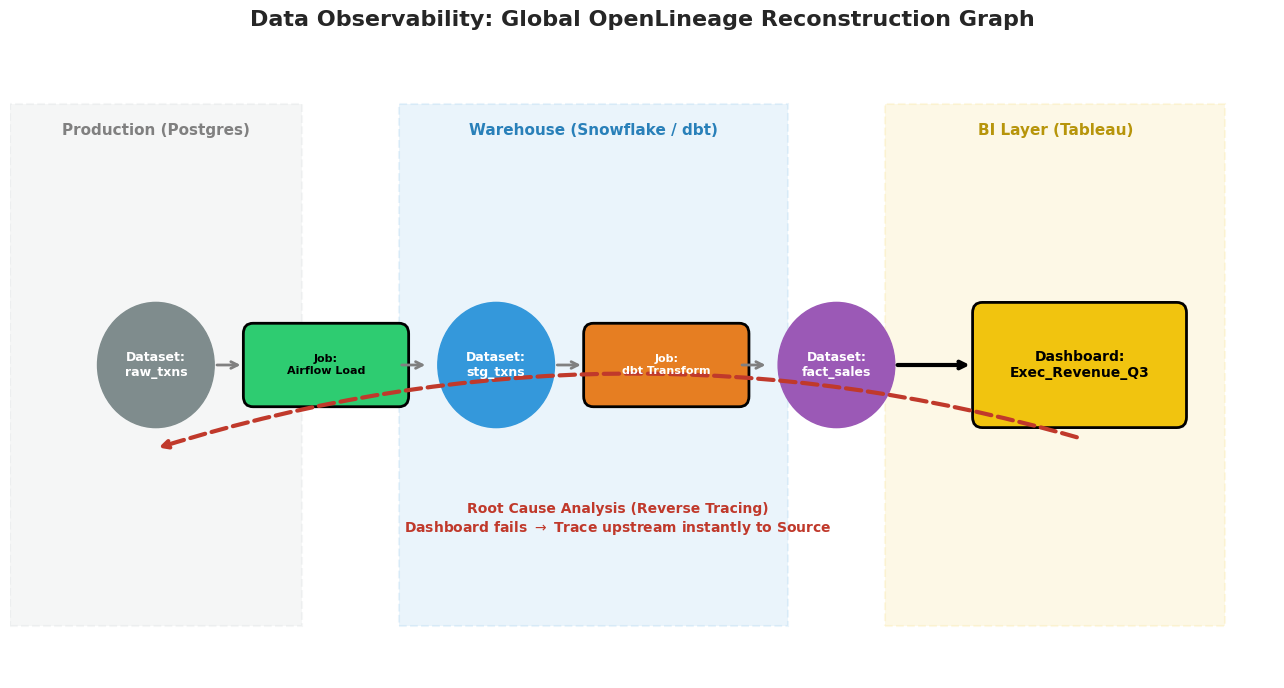

In [3]:
# Visualizing the Global Data Lineage Graph Topology
fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle("Data Observability: Global OpenLineage Reconstruction Graph", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Systems Zones (The decoupled environments)
ax.add_patch(patches.Rectangle((0, 0.5), 3, 5, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(1.5, 5.2, "Production (Postgres)", ha='center', color='gray', fontweight='bold', fontsize=11)

ax.add_patch(patches.Rectangle((4, 0.5), 4, 5, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(6, 5.2, "Warehouse (Snowflake / dbt)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

ax.add_patch(patches.Rectangle((9, 0.5), 3.5, 5, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(10.75, 5.2, "BI Layer (Tableau)", ha='center', color='#b7950b', fontweight='bold', fontsize=11)

# 2. Draw Datasets (Circles) and Jobs (Boxes)

# Source Dataset
ax.add_patch(patches.Circle((1.5, 3), 0.6, color='#7f8c8d', zorder=3))
ax.text(1.5, 3, "Dataset:\nraw_txns", ha='center', va='center', color='white', fontweight='bold', fontsize=9, zorder=4)

# Ingestion Job
ax.add_patch(patches.FancyBboxPatch((2.5, 2.7), 1.5, 0.6, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71', zorder=3))
ax.text(3.25, 3, "Job:\nAirflow Load", ha='center', va='center', color='black', fontweight='bold', fontsize=8, zorder=4)

# Intermediate Dataset
ax.add_patch(patches.Circle((5, 3), 0.6, color='#3498db', zorder=3))
ax.text(5, 3, "Dataset:\nstg_txns", ha='center', va='center', color='white', fontweight='bold', fontsize=9, zorder=4)

# Transform Job
ax.add_patch(patches.FancyBboxPatch((6, 2.7), 1.5, 0.6, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#e67e22', zorder=3))
ax.text(6.75, 3, "Job:\ndbt Transform", ha='center', va='center', color='white', fontweight='bold', fontsize=8, zorder=4)

# Final Warehouse Dataset
ax.add_patch(patches.Circle((8.5, 3), 0.6, color='#9b59b6', zorder=3))
ax.text(8.5, 3, "Dataset:\nfact_sales", ha='center', va='center', color='white', fontweight='bold', fontsize=9, zorder=4)

# BI Dashboard (Target)
ax.add_patch(patches.FancyBboxPatch((10, 2.5), 2, 1, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f1c40f', zorder=3))
ax.text(11, 3, "Dashboard:\nExec_Revenue_Q3", ha='center', va='center', color='black', fontweight='bold', fontsize=10, zorder=4)

# 3. Draw Directed Edges (The Lineage Paths reconstructed by the Server)
ax.annotate("", xy=(2.4, 3), xytext=(2.1, 3), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))
ax.annotate("", xy=(4.3, 3), xytext=(4.0, 3), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))
ax.annotate("", xy=(5.9, 3), xytext=(5.6, 3), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))
ax.annotate("", xy=(7.8, 3), xytext=(7.5, 3), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))
ax.annotate("", xy=(9.9, 3), xytext=(9.1, 3), arrowprops=dict(arrowstyle="->", lw=3, color="black"))

# 4. Draw Root Cause Analysis Tracker (The Reverse Path)
ax.annotate("", xy=(1.5, 2.2), xytext=(11, 2.3), arrowprops=dict(arrowstyle="->", lw=3, color="#c0392b", linestyle="dashed", connectionstyle="arc3,rad=0.15"))
ax.text(6.25, 1.4, "Root Cause Analysis (Reverse Tracing)\nDashboard fails $\\rightarrow$ Trace upstream instantly to Source", ha='center', fontweight='bold', color="#c0392b", fontsize=10)

plt.xlim(0, 13)
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Data Observability & Lineage like **Tracking the Global Supply Chain of a Contaminated Salad**:

* **No Observability (The Nightmare Scenario)**: A customer buys a salad at a grocery store in New York and gets terribly sick. The CDC calls the grocery store manager and asks, *"Where did this lettuce come from?"* The manager shrugs and says, *"A truck dropped it off."* The government must now blindly investigate 10,000 farms across the country. It takes months, people keep getting sick, and the grocery chain goes bankrupt. (This is a data pipeline without lineage. A dashboard breaks, and no one knows why).
* **OpenLineage (The Barcode Ledger)**: Every single movement of the lettuce is tracked via a global barcode system.
* The Farm (Source Dataset) puts a barcode on the crate and logs it into the server (START Event).
* The Trucking Company (Airflow Job) scans the crate when they pick it up and when they drop it off (COMPLETE Event).
* The Packaging Plant (dbt Transform) scans the crate as it goes into the bag.


* When the customer gets sick, the CDC types the final bag ID into the central server. The software instantly highlights a mathematically perfect line backwards through the graph, bypassing the grocery store, bypassing the trucking company, and pointing exactly to "Farm #42 in California." They isolate the problem in seconds.

By instrumenting your Data Engineering platforms with OpenLineage, you guarantee that when (not if) data breaks in production, you can trace the exact root cause in seconds, maintaining total executive trust.